#On First-Order Meta-Learning Algorithms

Nos centraremos en el método *Reptile* propuesto en el artículo, cuyo objetivo es encontrar una inicialización para los pesos de una red neuronal.

Para ello, la técnica selecciona repetidamente una tarea (en nuestro caso, un conjunto de imágenes de entrenamiento del CIFAR-10), entrena el modelo en ella durante varios pasos, y luego actualiza la inicialización moviéndola directamente hacia los pesos finales.

Finalmente, esta inicialización permite que la red se adapte rápidamente y con gran precisión a un conjunto de test compuesto por clases nuevas, utilizando muy pocos ejemplos.






In [10]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Comprobamos que estamos en versión 2.18.x o superior de TensorFlow

In [11]:
print(tf.__version__)

2.20.0


El repositorio original https://github.com/openai/supervised-reptile.git utiliza TensorFlow 1.x. Por lo que, a partir de su código, vamos a recrear el funcionamiento de reptile para una versión 2.20 de TensorFlow.

### Cargamos un subconjunto reducido de imagenes de CIFAR-10

Vamos a dividir las 5 primeras clases para conjunto de entrenamiento de nuestra red CNN, y las siguientes 5 clases se usaran para medir el rendimiento del método reptile.

In [36]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

print("CIFAR-10 shapes originales:",
      x_train.shape, y_train.shape, x_test.shape, y_test.shape)

# Normalizar a [0,1] float32
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Elegimos un subconjunto de clases y de imágenes por clase para que todo vaya rápido
N_WAY = 5                    # número de clases por tarea (5-way)
TRAIN_CLASSES = [0, 1, 2, 3, 4]    # IDs de clase que vamos a usar para entrenamiento
TEST_CLASSES = [5, 6, 7, 8, 9]    # IDs de clase que vamos a usar para test
TRAIN_PER_CLASS = 500        # imágenes por clase en meta-train
TEST_PER_CLASS = 250         # imágenes por clase en meta-test

def make_subset(x, y, classes, per_class):
    xs, ys = [], []
    for c in classes:
        idx = np.where(y == c)[0][:per_class]
        xs.append(x[idx])
        ys.append(np.full(len(idx), c, dtype=np.int64))
    xs = np.concatenate(xs, axis=0)
    ys = np.concatenate(ys, axis=0)
    return xs, ys

x_train_sub, y_train_sub = make_subset(x_train, y_train, TRAIN_CLASSES, TRAIN_PER_CLASS)
x_test_sub, y_test_sub = make_subset(x_test, y_test, TEST_CLASSES, TEST_PER_CLASS)

print("Subconjunto train:", x_train_sub.shape, y_train_sub.shape)
print("Subconjunto test: ", x_test_sub.shape, y_test_sub.shape)

CIFAR-10 shapes originales: (50000, 32, 32, 3) (50000,) (10000, 32, 32, 3) (10000,)
Subconjunto train: (2500, 32, 32, 3) (2500,)
Subconjunto test:  (1250, 32, 32, 3) (1250,)


##### Exploración visual del subconjunto seleccionado.

Imagenes del entrenamiento

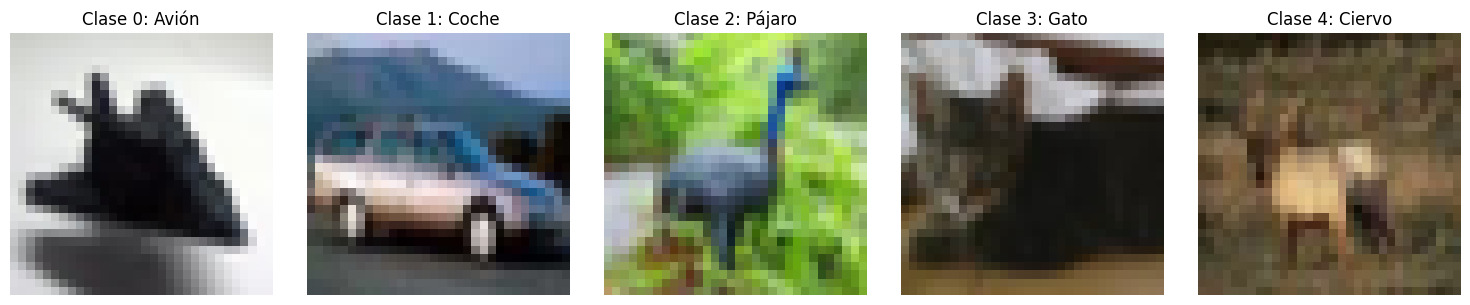

In [37]:
import matplotlib.pyplot as plt

# Creamos una figura con tantas columnas como clases (N_WAY)
fig, axes = plt.subplots(1, N_WAY, figsize=(15, 3))
class_names = ['Avión', 'Coche', 'Pájaro', 'Gato', 'Ciervo']

for i, class_id in enumerate(TRAIN_CLASSES):
    # Buscamos el índice de la primera aparición de esta clase en el subconjunto
    idx = np.where(y_train_sub == class_id)[0][0]

    # Extraemos la imagen correspondiente
    img = x_train_sub[idx]

    # La mostramos en el subplot correspondiente
    axes[i].imshow(img)
    axes[i].set_title(f"Clase {class_id}: {class_names[i]}")
    axes[i].axis("off")  # Ocultar los ejes para que se vea más limpio

plt.tight_layout()
plt.show()

Imagenes de prueba

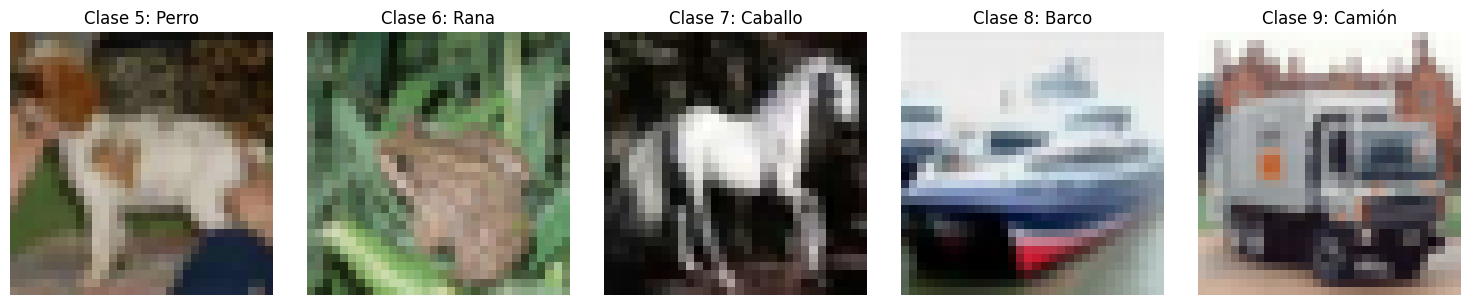

In [38]:
import matplotlib.pyplot as plt

# Creamos una figura con tantas columnas como clases (N_WAY)
fig, axes = plt.subplots(1, N_WAY, figsize=(15, 3))
class_names = ['Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

for i, class_id in enumerate(TEST_CLASSES):
    # Buscamos el índice de la primera aparición de esta clase en el subconjunto
    idx = np.where(y_test_sub == class_id)[0][0]

    # Extraemos la imagen correspondiente
    img = x_test_sub[idx]

    # La mostramos en el subplot correspondiente
    axes[i].imshow(img)
    axes[i].set_title(f"Clase {class_id}: {class_names[i]}")
    axes[i].axis("off")  # Ocultar los ejes para que se vea más limpio

plt.tight_layout()
plt.show()

### Método reptile

Definimos una función auxiliar que nos sirva para seleccionar un conjunto de imagenes/clases para soporte y prueba para el método reptile.

Para ello se le proporciona:


*   **n_way** = número de clases (fijado en 5 desde la selección de CIFAR-10).
*   **k_shot** = número de muestras por clase para entrenamiento.
*   **q_querry** = número de muestras por clase para validación.




In [26]:
semilla = np.random.default_rng(42) # Para reproducir el experimento

def sample_task(x, y, available_classes, n_way=5, k_shot=1, q_query=15):
    """
    Devuelve (support_x, support_y, query_x, query_y) para una tarea N-way K-shot.
    Las etiquetas se remapean a {0,...,N-1} para que el modelo siempre tenga N salidas.
    """
    classes = semilla.choice(available_classes, size=n_way, replace=False)
    support_x, support_y = [], []
    query_x, query_y = [], []

    for new_label, c in enumerate(classes):
        idx = np.where(y == c)[0]
        idx = semilla.permutation(idx)
        support_idx = idx[:k_shot]
        query_idx = idx[k_shot:k_shot + q_query]
        support_x.append(x[support_idx])
        support_y.append(np.full(len(support_idx), new_label, dtype=np.int64))
        query_x.append(x[query_idx])
        query_y.append(np.full(len(query_idx), new_label, dtype=np.int64))

    support_x = np.concatenate(support_x, axis=0)
    support_y = np.concatenate(support_y, axis=0)
    query_x = np.concatenate(query_x, axis=0)
    query_y = np.concatenate(query_y, axis=0)
    return support_x, support_y, query_x, query_y

# Prueba rápida del sampler
sx, sy, qx, qy = sample_task(x_train_sub, y_train_sub, TRAIN_CLASSES, n_way=N_WAY, k_shot=1, q_query=5)
print("Ejemplo de tarea: support", sx.shape, sy.shape, "query", qx.shape, qy.shape)

Ejemplo de tarea: support (5, 32, 32, 3) (5,) query (25, 32, 32, 3) (25,)


Modelo base de CNN base para probar el funcionamiento del método reptile.

In [27]:

def build_cifar10_fewshot_model(n_classes, input_shape=(32, 32, 3)):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for filters in [32, 64, 64]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.BatchNormalization()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    return model


meta_model = build_cifar10_fewshot_model(N_WAY)
meta_model.summary()


Model: "functional_5619"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5619 (InputLayer)   │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16857 (Conv2D)           │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16857             │ (None, 16, 16, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16857       │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16858 (Conv2D)           │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16858             │ (None, 8, 8, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16858       │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16859 (Conv2D)           │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16859             │ (None, 4, 4, 64)       │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16859       │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5619 (Flatten)          │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11238 (Dense)             │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5619 (Dropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11239 (Dense)             │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,645 (1.22 MB)

 Trainable params: 320,325 (1.22 MB)

 Non-trainable params: 320 (1.25 KB)

Implementación de Reptile con los siguientes hiperparámetros:
* **inner_lr** : factor de aprendizaje fase interna
* **meta_lr** : factor de aprendizaje para las nuevas tareas
* **inner_steps**: número de pasos de gradiente que se da dentro de cada tarea antes de hacer la actualización meta.
* **meta_batch_size**: cuántas tareas se muestrea en cada iteración meta antes de actualizar la inicialización.
* **meta_iters**: es el número total de veces que se repite el ciclo muestrear tareas $\rightarrow$ entrenar en ellas $\rightarrow$ actualizar la inicialización

In [28]:
inner_lr = 0.01            # lr del inner loop
meta_lr = 0.1              # paso meta (Reptile)
inner_steps = 5            # pasos de gradiente por tarea
meta_batch_size = 5        # tareas por iteración meta
meta_iters = 1000           # iteraciones meta (1% del original)

loss_fn = keras.losses.SparseCategoricalCrossentropy()

# @tf.function # Eliminamos el decorador tf.function
def inner_update(model, x, y, steps):
    """
    Ejecuta 'steps' pasos de gradiente sobre (x, y) y devuelve los pesos actualizados.
    """
    # Creamos el optimizador aquí para que se asocie con las variables del modelo actual
    task_optimizer = keras.optimizers.SGD(inner_lr)
    for _ in tf.range(steps):
        with tf.GradientTape() as tape:
            logits = model(x, training=True)
            loss = loss_fn(y, logits)
        grads = tape.gradient(loss, model.trainable_weights)
        task_optimizer.apply_gradients(zip(grads, model.trainable_weights)) # Usamos el optimizador de la tarea
    return model.trainable_weights

def reptile_meta_train(meta_model,
                       x_train, y_train,
                       n_way=5,
                       k_shot=1,
                       q_query=15,
                       meta_iters=meta_iters,
                       meta_batch_size=meta_batch_size,
                       inner_steps=inner_steps,
                       meta_lr=meta_lr):
    """
    Bucle principal de Reptile: actualiza meta_model sobre muchas tareas few-shot.
    """
    for meta_iter in range(1, meta_iters + 1):
        # Guardar copia de los pesos actuales
        old_weights = meta_model.get_weights()
        # Acumulador de deltas
        weight_deltas = [np.zeros_like(w) for w in old_weights]

        task_model = build_cifar10_fewshot_model(n_way)
        for task in range(meta_batch_size):
            # Sobreescribir pesos
            task_model.set_weights(old_weights)

            # Muestrear una tarea
            sx, sy, qx, qy = sample_task(x_train, y_train, TRAIN_CLASSES,
                                         n_way=n_way,
                                         k_shot=k_shot,
                                         q_query=q_query)

            sx_tf = tf.convert_to_tensor(sx)
            sy_tf = tf.convert_to_tensor(sy, dtype=tf.int32)

            # Inner loop
            _ = inner_update(task_model, sx_tf, sy_tf, inner_steps)

            # Delta de pesos
            new_weights = task_model.get_weights()
            for i, (w_old, w_new) in enumerate(zip(old_weights, new_weights)):
                weight_deltas[i] += (w_new - w_old)

        # Actualización meta (media de tareas)
        new_meta_weights = [
            w_old + meta_lr * delta / meta_batch_size
            for w_old, delta in zip(old_weights, weight_deltas)
        ]
        meta_model.set_weights(new_meta_weights)

        # Logging simple
        if meta_iter % 10 == 0 or meta_iter == 1:
            print(f"[Meta-iter {meta_iter}/{meta_iters}] actualizado meta-modelo.")

### Experimentos

Función de evaluación few-shot

Nota: vamos a aumentar inner_steps de $5$ a $50$ para sobreajustar más durante el conjunto de prueba.

In [34]:

def evaluate_few_shot(meta_model,
                      x_data, y_data,
                      n_way=5,
                      k_shot=1,
                      q_query=15,
                      episodes=100,
                      available_classes=TEST_CLASSES): # Agregamos available_classes con default a TEST_CLASSES
    """
    Evalúa la inicialización meta-modelo en episodios N-way K-shot
    """
    accuracies = []
    for ep in range(episodes):
        # Copia del modelo meta
        model = build_cifar10_fewshot_model(n_way)
        model.set_weights(meta_model.get_weights())

        sx, sy, qx, qy = sample_task(x_data, y_data, available_classes,
                                     n_way=n_way,
                                     k_shot=k_shot,
                                     q_query=q_query)

        sx_tf = tf.convert_to_tensor(sx)
        sy_tf = tf.convert_to_tensor(sy, dtype=tf.int32)
        qx_tf = tf.convert_to_tensor(qx)
        qy_tf = tf.convert_to_tensor(qy, dtype=tf.int32)

        # Unos cuantos pasos de adaptación en la tarea
        eval_inner_steps = 50 # Aumentamos el paso durante test para sobreajustar mas
        _ = inner_update(model, sx_tf, sy_tf, eval_inner_steps)

        # Evaluar en el query set
        logits = model(qx_tf, training=False)
        preds = tf.argmax(logits, axis=-1, output_type=tf.int32)
        acc = tf.reduce_mean(tf.cast(tf.equal(preds, qy_tf), tf.float32)).numpy()
        accuracies.append(acc)

    return float(np.mean(accuracies)), float(np.std(accuracies))

#### Entrenamiento y evaluación del modelo

Como estamos evaluando un método de inicialización de pesos para pocos datos. Vamos a medir el rendimiento del algoritmo variando $K$ (número de muestras de cada clase) entre $1$ y $5$.

Vamos a realizar una prueba para entrenar inicialización de CNN tan solo con 100 iteraciones sobre el conjunto de entrenamiento.

In [30]:
meta_iters = 100           # iteraciones meta (0.1% del original) para mayor velocidad

print("Entrenando meta-modelo (Reptile) con un número reducido de iteraciones...")
reptile_meta_train(
    meta_model,
    x_train_sub, y_train_sub,
    n_way=N_WAY,
    k_shot=1,       # 1-shot
    q_query=15,
    meta_iters=meta_iters,
    meta_batch_size=meta_batch_size,
    inner_steps=inner_steps,
    meta_lr=meta_lr,
)

print("\nEvaluando 5-way 1-shot...")
mean_acc_1, std_acc_1 = evaluate_few_shot(
    meta_model,
    x_test_sub, y_test_sub,
    n_way=N_WAY,
    k_shot=1,
    q_query=15,
    episodes=100,
    available_classes=TEST_CLASSES
)
print(f"5-way 1-shot accuracy: {mean_acc_1*100:.2f}% +/- {1.96*std_acc_1/np.sqrt(100)*100:.2f}%")

print("\nEvaluando 5-way 2-shot...")
mean_acc_2, std_acc_2 = evaluate_few_shot(
    meta_model,
    x_test_sub, y_test_sub,
    n_way=N_WAY,
    k_shot=2,
    q_query=15,
    episodes=100,
    available_classes=TEST_CLASSES
)
print(f"5-way 2-shot accuracy: {mean_acc_2*100:.2f}% +/- {1.96*std_acc_2/np.sqrt(100)*100:.2f}%")

print("\nEvaluando 5-way 3-shot...")
mean_acc_3, std_acc_3 = evaluate_few_shot(
    meta_model,
    x_test_sub, y_test_sub,
    n_way=N_WAY,
    k_shot=3,
    q_query=15,
    episodes=100,
    available_classes=TEST_CLASSES
)
print(f"5-way 3-shot accuracy: {mean_acc_3*100:.2f}% +/- {1.96*std_acc_3/np.sqrt(100)*100:.2f}%")

print("\nEvaluando 5-way 4-shot...")
mean_acc_4, std_acc_4 = evaluate_few_shot(
    meta_model,
    x_test_sub, y_test_sub,
    n_way=N_WAY,
    k_shot=4,
    q_query=15,
    episodes=100,
    available_classes=TEST_CLASSES
)
print(f"5-way 4-shot accuracy: {mean_acc_4*100:.2f}% +/- {1.96*std_acc_4/np.sqrt(100)*100:.2f}%")

print("\nEvaluando 5-way 5-shot...")
mean_acc_5, std_acc_5 = evaluate_few_shot(
    meta_model,
    x_test_sub, y_test_sub,
    n_way=N_WAY,
    k_shot=5,
    q_query=15,
    episodes=100,
    available_classes=TEST_CLASSES
)
print(f"5-way 5-shot accuracy: {mean_acc_5*100:.2f}% +/- {1.96*std_acc_5/np.sqrt(100)*100:.2f}%")


Entrenando meta-modelo (Reptile) con un número reducido de iteraciones...
[Meta-iter 1/100] actualizado meta-modelo.
[Meta-iter 10/100] actualizado meta-modelo.
[Meta-iter 20/100] actualizado meta-modelo.
[Meta-iter 30/100] actualizado meta-modelo.
[Meta-iter 40/100] actualizado meta-modelo.
[Meta-iter 50/100] actualizado meta-modelo.
[Meta-iter 60/100] actualizado meta-modelo.
[Meta-iter 70/100] actualizado meta-modelo.
[Meta-iter 80/100] actualizado meta-modelo.
[Meta-iter 90/100] actualizado meta-modelo.
[Meta-iter 100/100] actualizado meta-modelo.

Evaluando 5-way 1-shot...
5-way 1-shot accuracy: 20.83% +/- 0.45%

Evaluando 5-way 2-shot...
5-way 2-shot accuracy: 20.33% +/- 0.37%

Evaluando 5-way 3-shot...
5-way 1+3-shot accuracy: 20.09% +/- 0.32%

Evaluando 5-way 4-shot...
5-way 4-shot accuracy: 20.17% +/- 0.32%

Evaluando 5-way 5-shot...
5-way 5-shot accuracy: 20.64% +/- 0.42%


Resulta que al aumentar el número de shots no observamos ninguna mejora, obteniendo un porcentaje de acierto entorno al 20%. Por lo que suponemos que nuestra CNN realiza predicciones son aleatorias (acierta 1/5 imagenes de 5 clases diferentes).

Es posible que los malos resultados puedan deberse por dos motivos:
* La red CNN que hemos construido, no tiene capacidad suficiente para la clasificación de CIFAR-10 (poco probable)
* El número de iteraciones usada para el entrenamiento de reptile es insuficiente.

Como en el artículo original usaban 100000 que son x100 respecto a las usadas anteriormente, vamos a aumentar el número de iteraciones para tratar de mejorar los resultados.

Vamos a realizar una prueba para entrenar nuestra CNN aumentando las iteraciones de 100 a 2000.

In [31]:
meta_iters = 2000           # iteraciones meta (2% del original) para mejor rendimiento

print("Entrenando meta-modelo (Reptile) con un número reducido de iteraciones...")
reptile_meta_train(
    meta_model,
    x_train_sub, y_train_sub,
    n_way=N_WAY,
    k_shot=1,       # 1-shot
    q_query=15,
    meta_iters=meta_iters,
    meta_batch_size=meta_batch_size,
    inner_steps=inner_steps,
    meta_lr=meta_lr,
)

print("\nEvaluando 5-way 1-shot...")
mean_acc_1, std_acc_1 = evaluate_few_shot(
    meta_model,
    x_test_sub, y_test_sub,
    n_way=N_WAY,
    k_shot=1,
    q_query=15,
    episodes=100,
    available_classes=TEST_CLASSES
)
print(f"5-way 1-shot accuracy: {mean_acc_1*100:.2f}% +/- {1.96*std_acc_1/np.sqrt(100)*100:.2f}%")

print("\nEvaluando 5-way 2-shot...")
mean_acc_2, std_acc_2 = evaluate_few_shot(
    meta_model,
    x_test_sub, y_test_sub,
    n_way=N_WAY,
    k_shot=2,
    q_query=15,
    episodes=100,
    available_classes=TEST_CLASSES
)
print(f"5-way 2-shot accuracy: {mean_acc_2*100:.2f}% +/- {1.96*std_acc_2/np.sqrt(100)*100:.2f}%")

print("\nEvaluando 5-way 3-shot...")
mean_acc_3, std_acc_3 = evaluate_few_shot(
    meta_model,
    x_test_sub, y_test_sub,
    n_way=N_WAY,
    k_shot=3,
    q_query=15,
    episodes=100,
    available_classes=TEST_CLASSES
)
print(f"5-way 3-shot accuracy: {mean_acc_3*100:.2f}% +/- {1.96*std_acc_3/np.sqrt(100)*100:.2f}%")

print("\nEvaluando 5-way 4-shot...")
mean_acc_4, std_acc_4 = evaluate_few_shot(
    meta_model,
    x_test_sub, y_test_sub,
    n_way=N_WAY,
    k_shot=4,
    q_query=15,
    episodes=100,
    available_classes=TEST_CLASSES
)
print(f"5-way 4-shot accuracy: {mean_acc_4*100:.2f}% +/- {1.96*std_acc_4/np.sqrt(100)*100:.2f}%")

print("\nEvaluando 5-way 5-shot...")
mean_acc_5, std_acc_5 = evaluate_few_shot(
    meta_model,
    x_test_sub, y_test_sub,
    n_way=N_WAY,
    k_shot=5,
    q_query=15,
    episodes=100,
    available_classes=TEST_CLASSES
)
print(f"5-way 5-shot accuracy: {mean_acc_5*100:.2f}% +/- {1.96*std_acc_5/np.sqrt(100)*100:.2f}%")


Entrenando meta-modelo (Reptile) con un número reducido de iteraciones...
[Meta-iter 1/2000] actualizado meta-modelo.
[Meta-iter 10/2000] actualizado meta-modelo.
[Meta-iter 20/2000] actualizado meta-modelo.
[Meta-iter 30/2000] actualizado meta-modelo.
[Meta-iter 40/2000] actualizado meta-modelo.
[Meta-iter 50/2000] actualizado meta-modelo.
[Meta-iter 60/2000] actualizado meta-modelo.
[Meta-iter 70/2000] actualizado meta-modelo.
[Meta-iter 80/2000] actualizado meta-modelo.
[Meta-iter 90/2000] actualizado meta-modelo.
[Meta-iter 100/2000] actualizado meta-modelo.
[Meta-iter 110/2000] actualizado meta-modelo.
[Meta-iter 120/2000] actualizado meta-modelo.
[Meta-iter 130/2000] actualizado meta-modelo.
[Meta-iter 140/2000] actualizado meta-modelo.
[Meta-iter 150/2000] actualizado meta-modelo.
[Meta-iter 160/2000] actualizado meta-modelo.
[Meta-iter 170/2000] actualizado meta-modelo.
[Meta-iter 180/2000] actualizado meta-modelo.
[Meta-iter 190/2000] actualizado meta-modelo.
[Meta-iter 200/20

Ahora si que hemos logrado mostrar unos resultado que no reflejan una clasificación aleatoria.

Cuantas más imágenes proporcionemos de cada clase, mejores serán los resultados obtenidos. Aunque para 1 imagen obtenemos tan solo un 5% más que la clasificación aleatoria, lo que resulta sorprendente es que con 3 imagenes adicionales logramos subir el acierto de un 26.2% a un 33.5%.

Esto último refleja la efectividad de la técnica, logrando obtener resultados decentes para un entrenamiento con muy pocos datos.

Por curiosidad, vamos a mostrar el rendimiento que se obtienen si se usan los datos de entrenamiento.

Como se han usado estas clases para actualizar la inicialización, se espera un rendimiento igual o superior que para el caso anterior.

In [35]:
print("Capacidad del modelo: \n Evaluando capacidad en clases de ENTRENAMIENTO ---")
# Usamos 5-shot para darle una buena cantidad de información a la red
# y ver su potencial máximo en las clases que ya conoce.

mean_acc_train, std_acc_train = evaluate_few_shot(
    meta_model,
    x_train_sub, y_train_sub,
    n_way=N_WAY,
    k_shot=5,
    q_query=15,
    episodes=100,
    available_classes=TRAIN_CLASSES # Para TRAIN_CLASSES
)

print(f"Precisión en datos conocidos (Train 5-way 5-shot): {mean_acc_train*100:.2f}% +/- {1.96*std_acc_train/np.sqrt(100)*100:.2f}%")

Capacidad del modelo: 
 Evaluando capacidad en clases de ENTRENAMIENTO ---
Precisión en datos conocidos (Train 5-way 5-shot): 33.84% +/- 1.13%


Resulta que la inicialización de los pesos tiene efecto positivo para las clases de entrenamiento, aunque espera observar un mayor acierto medio respecto del conjunto de test.

Sugiere que estamos inicializando los pesos en una región que resulta buena para todas las clases.

## Reflexiones finales

La técnica Reptile se basa en una idea simple para encontrar una inicialización de pesos general que permita a la red neuronal adaptarse rápidamente a tareas nuevas, como clases no vistas previamente, suponiendo que las nuevas clases pertenecen a un dominio similar.

Durante la realización de este trabajo, la implementación de la técnica Reptile a partir del repositorio original (de hace 8 años) a una versión más reciente de TensorFlow me requirió de un tiempo adicional para lograr reproducir los experimentos.

Al tratar de replicar los resultados, tuve que modificar los parámetros usados en el artículo debido a que resultaba computacionalmente inviable para Google Colab. Los autores utilizaron 100.000 iteraciones de meta-entrenamiento sobre 64 clases para mini-ImageNet. Al adaptar el experimento para Google Colab y CIFAR-10, el rendimiento de la técnica se aleja bastante de las cifras del estudio original.

De la implementación en este trabajo saco dos conclusiones finales sobre la técnica Reptile:
* Resulta que se requiere de un entrenamiento mucho mayor para mostrar el gran potencial que reflejan en el artículo. Es muy probable que con más recursos, hubiera logrado sacar resultados similares.
* Aún con bajos recursos, se percibe una mejora aunque sea de manera moderada. Lo que confirma que la inicialización general alcanzada logra una inicialización de pesos útiles, facilitando la generalización y el aprendizaje posterior con muy pocos datos



Trabajo realizado por Manuel Enciso Martínez

---